<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path =kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.


In [3]:
import os
os.listdir(path)

['WA_Fn-UseC_-HR-Employee-Attrition.csv']

In [4]:
df=pd.read_csv(path+'/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [6]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
424,57,No,Travel_Rarely,210,Sales,29,3,Marketing,1,568,...,3,80,1,32,3,2,1,0,0,0
922,44,No,Travel_Rarely,1199,Research & Development,4,2,Life Sciences,1,1288,...,4,80,2,26,4,2,25,9,14,13
576,27,No,Travel_Frequently,829,Sales,8,1,Marketing,1,800,...,2,80,1,5,3,3,4,2,1,1
1244,30,No,Travel_Frequently,1312,Research & Development,2,4,Technical Degree,1,1745,...,4,80,0,10,2,3,9,7,0,7
17,22,No,Non-Travel,1123,Research & Development,16,2,Medical,1,22,...,2,80,2,1,2,2,1,0,0,0


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

<Axes: xlabel='Age', ylabel='TotalWorkingYears'>

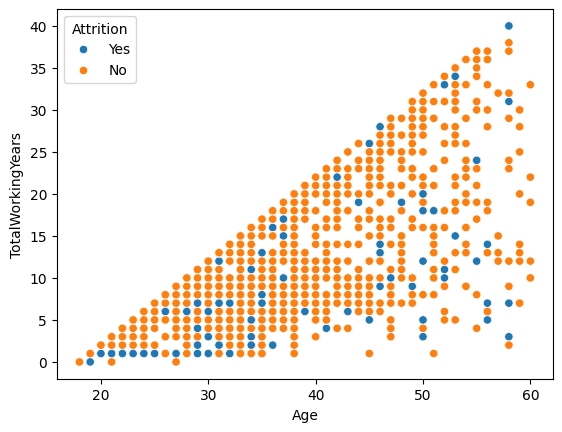

In [11]:
sns.scatterplot(df,x='Age',y='TotalWorkingYears',hue='Attrition')

<Axes: xlabel='Age', ylabel='DailyRate'>

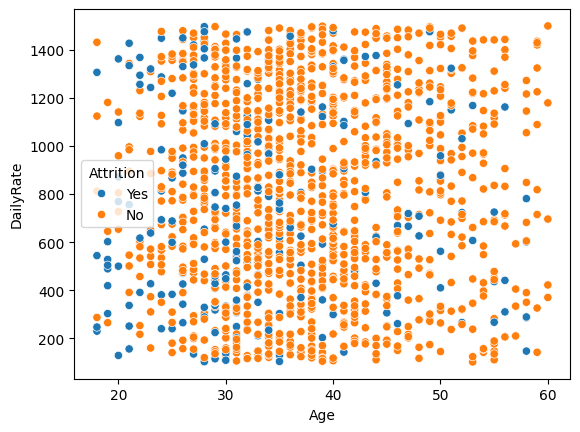

In [9]:
sns.scatterplot(df,x='Age',y='DailyRate',hue='Attrition')

In [12]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

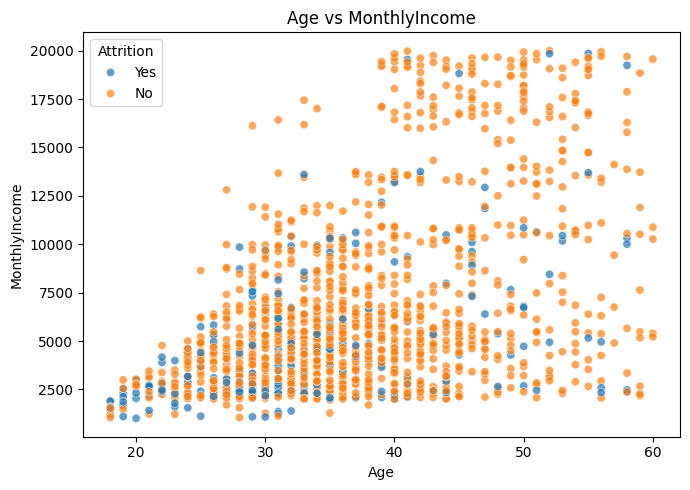

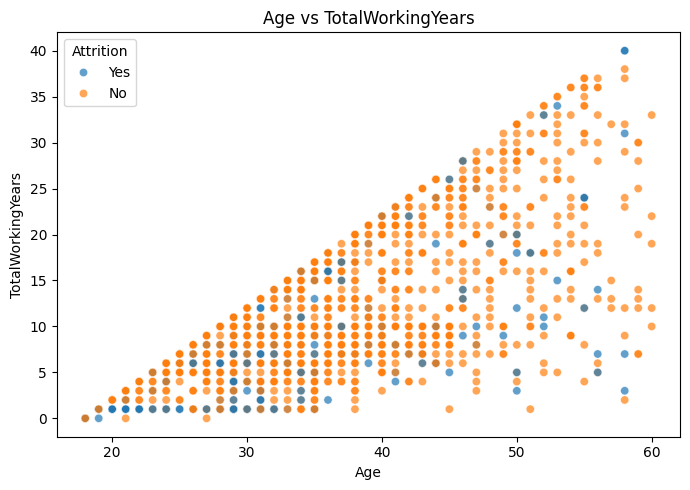

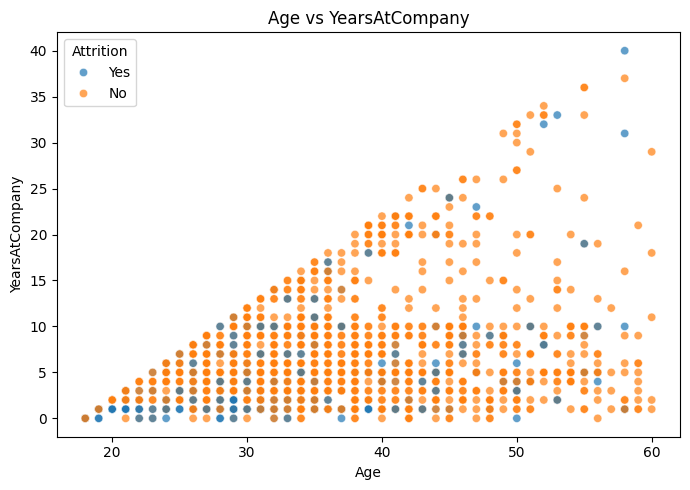

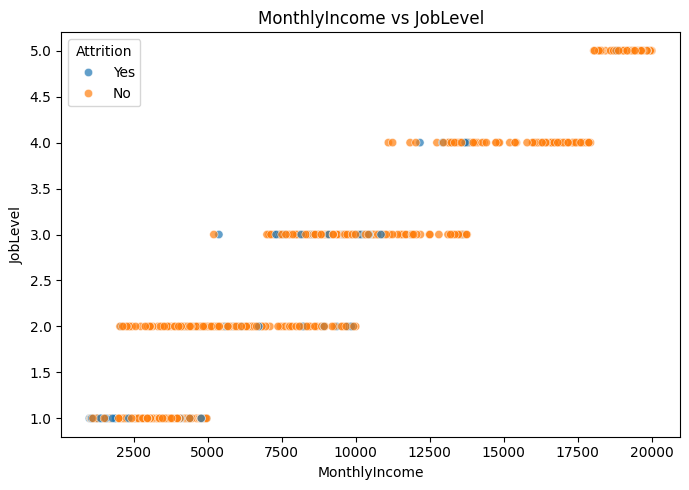

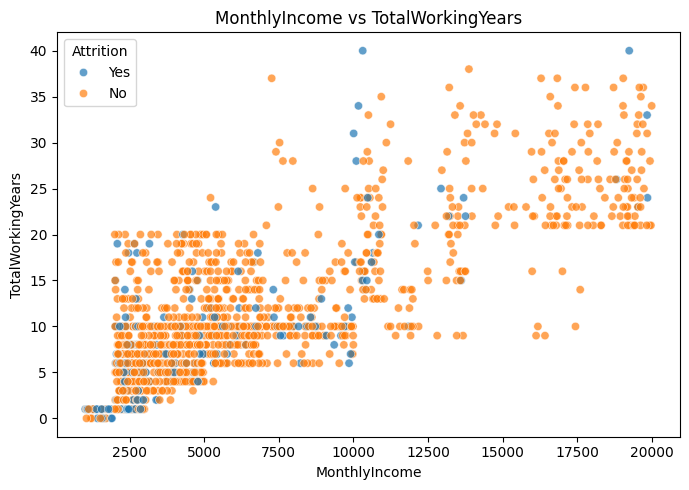

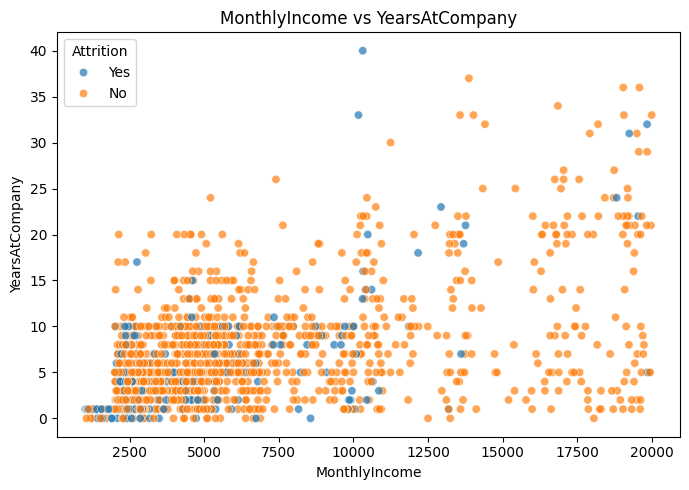

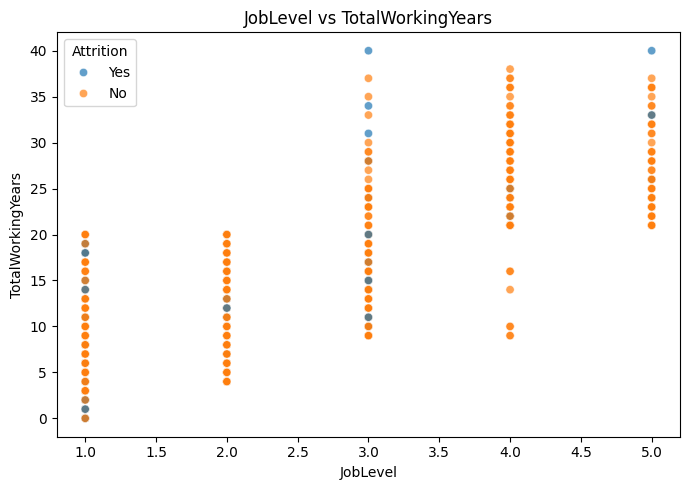

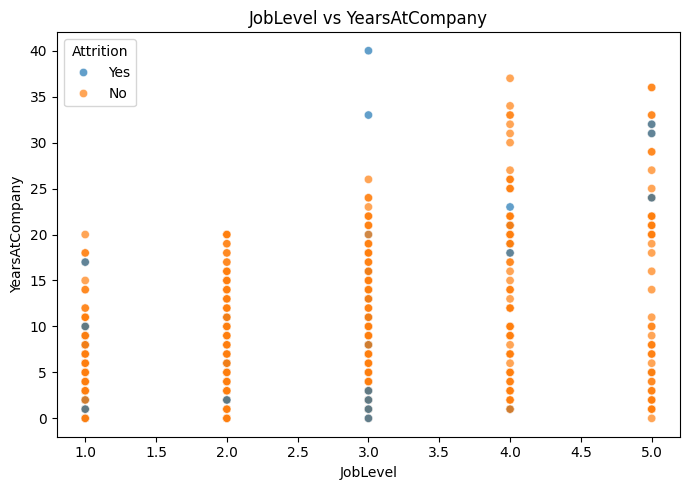

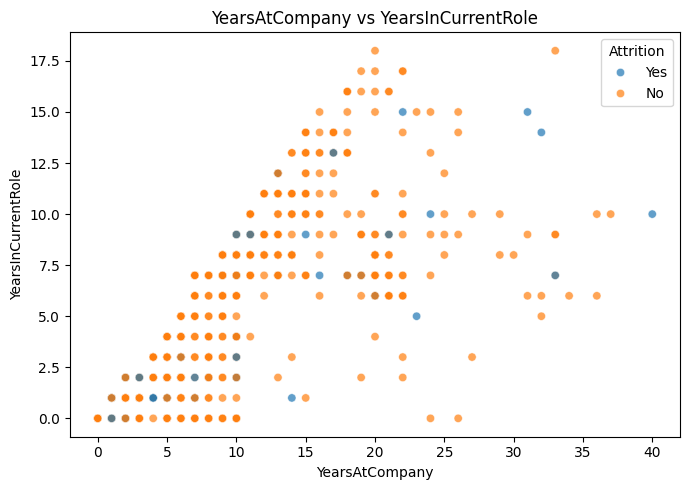

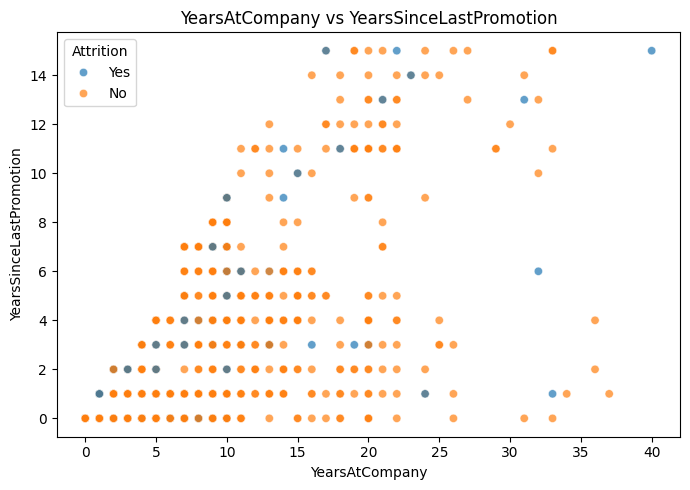

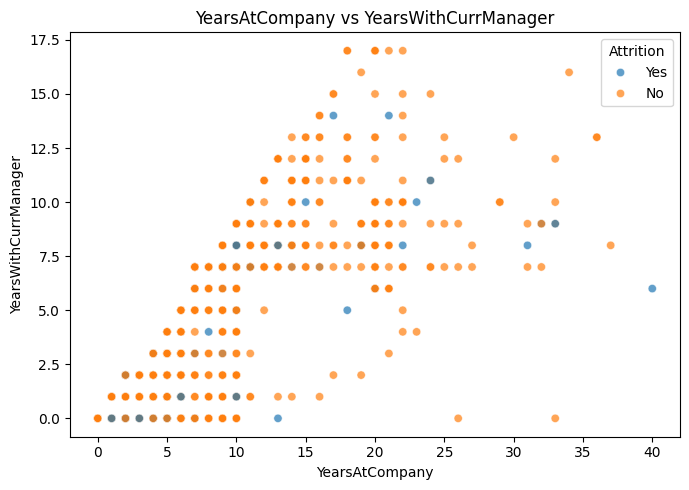

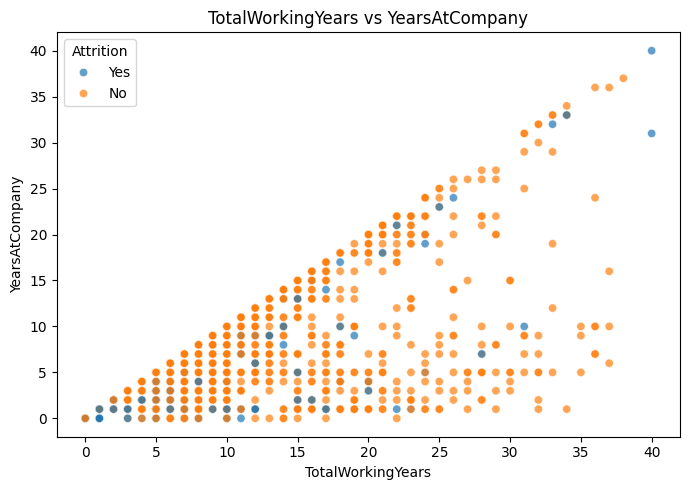

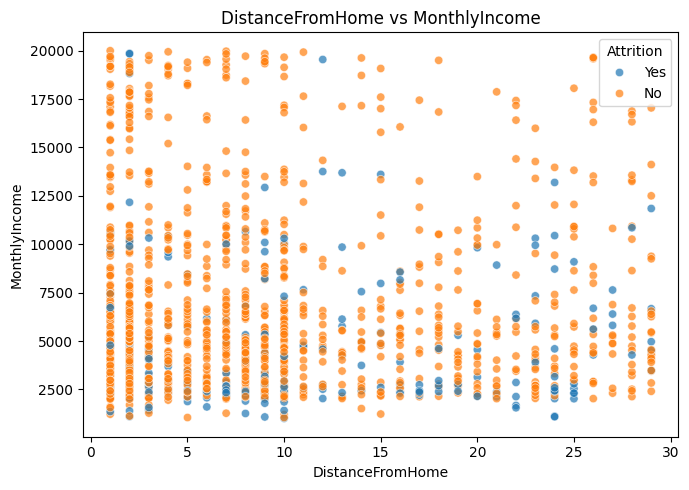

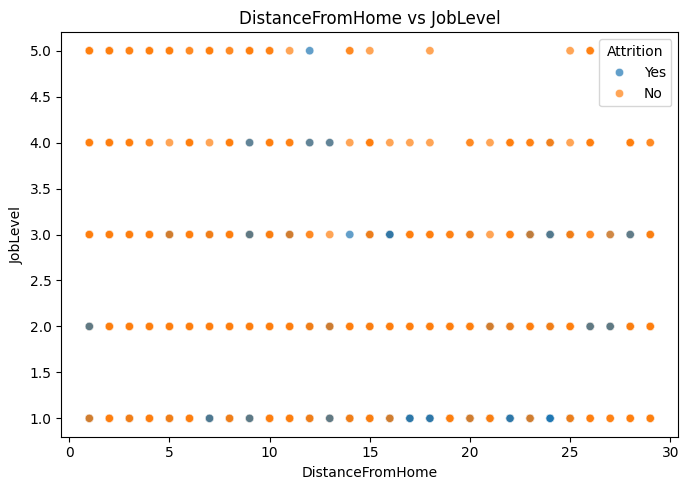

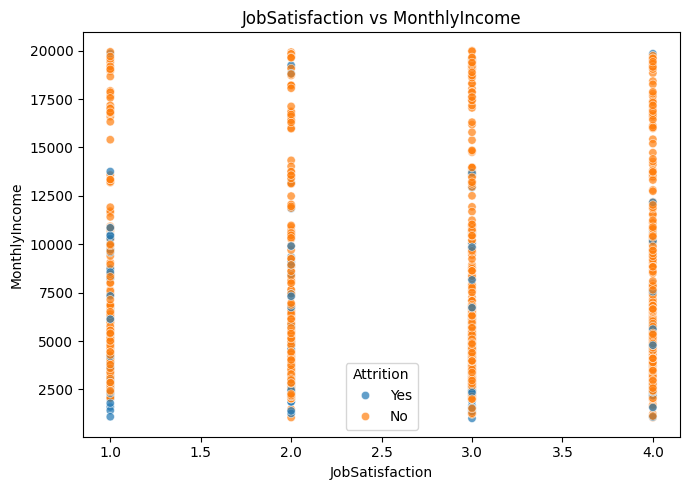

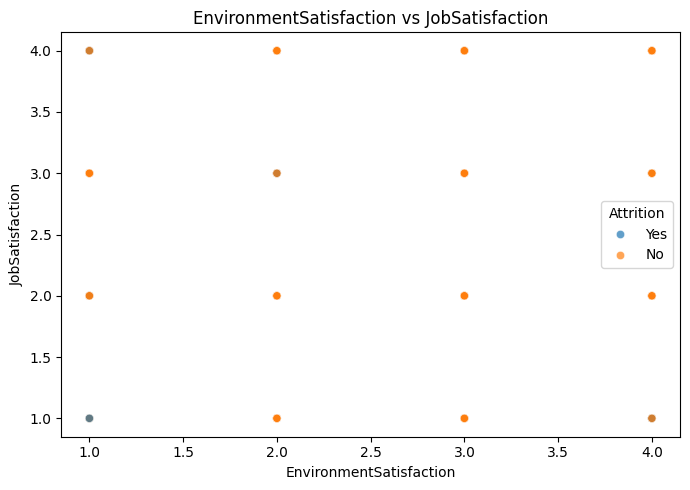

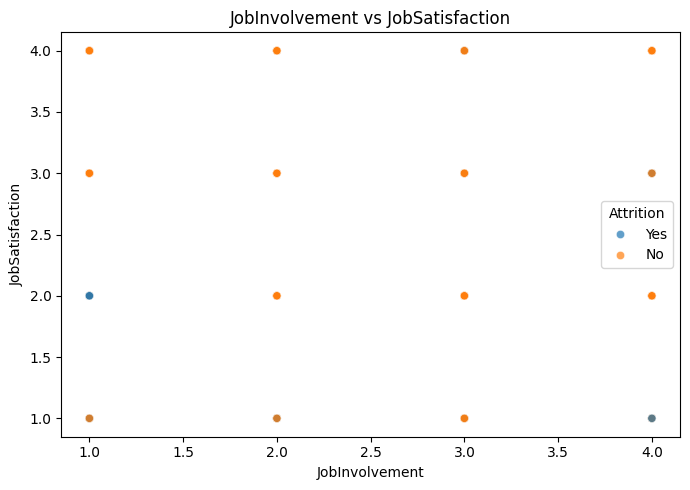

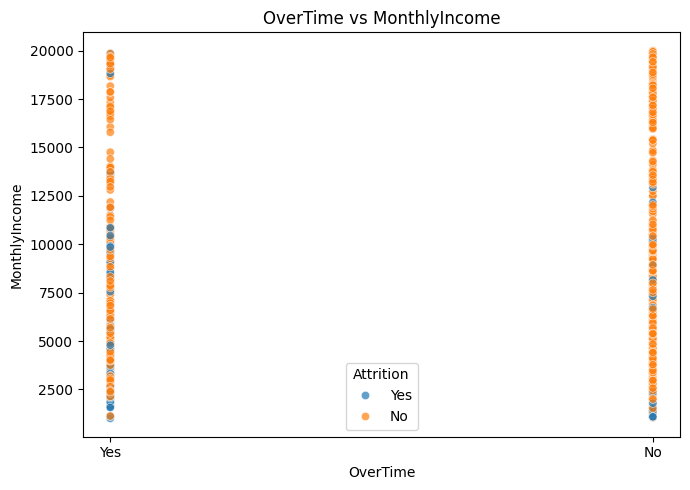

In [13]:


pairs = [
    ('Age', 'MonthlyIncome'),
    ('Age', 'TotalWorkingYears'),
    ('Age', 'YearsAtCompany'),
    ('MonthlyIncome', 'JobLevel'),
    ('MonthlyIncome', 'TotalWorkingYears'),
    ('MonthlyIncome', 'YearsAtCompany'),
    ('JobLevel', 'TotalWorkingYears'),
    ('JobLevel', 'YearsAtCompany'),
    ('YearsAtCompany', 'YearsInCurrentRole'),
    ('YearsAtCompany', 'YearsSinceLastPromotion'),
    ('YearsAtCompany', 'YearsWithCurrManager'),
    ('TotalWorkingYears', 'YearsAtCompany'),
    ('DistanceFromHome', 'MonthlyIncome'),
    ('DistanceFromHome', 'JobLevel'),
    ('JobSatisfaction', 'MonthlyIncome'),
    ('EnvironmentSatisfaction', 'JobSatisfaction'),
    ('JobInvolvement', 'JobSatisfaction'),
    ('OverTime', 'MonthlyIncome')
]

for x, y in pairs:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue='Attrition',
        alpha=0.7
    )
    plt.title(f'{x} vs {y}')
    plt.tight_layout()
    plt.show()

In [14]:
categorical_cols=['BusinessTravel', 'Department', 'EducationField',
             'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

X_cat = ohe.fit_transform(df[categorical_cols])



In [18]:
X_cat=pd.DataFrame(X_cat)

In [20]:
df=df.drop(categorical_cols,axis=1)

In [21]:
df_trf=pd.concat([df,X_cat],axis=1)

In [22]:
df_trf.sample(5)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,11,12,13,14,15,16,17,18,19,20
1249,29,Yes,428,9,3,1,1752,2,52,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1261,38,No,833,18,3,1,1766,2,60,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1175,39,No,492,12,3,1,1654,4,66,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
667,41,Yes,1085,2,4,1,927,2,57,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1224,26,No,390,17,4,1,1718,4,62,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [29]:
df_trf['Over18']

,Over18
0,Y
1,Y
2,Y
3,Y
4,Y
...,...
1465,Y
1466,Y
1467,Y
1468,Y


In [42]:
x_train,x_test,y_train,y_test=train_test_split(df_trf.drop('Attrition',axis=1),df_trf['Attrition'],test_size=0.2,random_state=42)

In [36]:
df_trf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   DailyRate                 1470 non-null   int64  
 3   DistanceFromHome          1470 non-null   int64  
 4   Education                 1470 non-null   int64  
 5   EmployeeCount             1470 non-null   int64  
 6   EmployeeNumber            1470 non-null   int64  
 7   EnvironmentSatisfaction   1470 non-null   int64  
 8   HourlyRate                1470 non-null   int64  
 9   JobInvolvement            1470 non-null   int64  
 10  JobLevel                  1470 non-null   int64  
 11  JobSatisfaction           1470 non-null   int64  
 12  MonthlyIncome             1470 non-null   int64  
 13  MonthlyRate               1470 non-null   int64  
 14  NumCompa

In [43]:
le=LabelEncoder()
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [44]:
le=LabelEncoder()
x_train['Over18']=le.fit_transform(x_train['Over18'])
x_test['Over18']=le.transform(x_test['Over18'])

In [46]:
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [48]:
rf=RandomForestClassifier()
x_train.columns = x_train.columns.astype(str)
rf.fit(x_train,y_train.values.ravel())

RandomForestClassifier()

In [50]:
x_test.columns = x_test.columns.astype(str)
y_pred=rf.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8809523809523809
